In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("car data.csv")  # update path if needed

In [4]:
print("First 5 rows:\n", df.head())


First 5 rows:
   Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [5]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [11]:
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
brand            0
dtype: int64


In [12]:
df['brand'] = df['Car_Name'].apply(lambda x: x.split()[0])

In [14]:
df.drop('Car_Name', axis=1, inplace=True)


In [16]:
df['car_age'] = 2024 - df['Year']
df.drop('Year', axis=1, inplace=True)


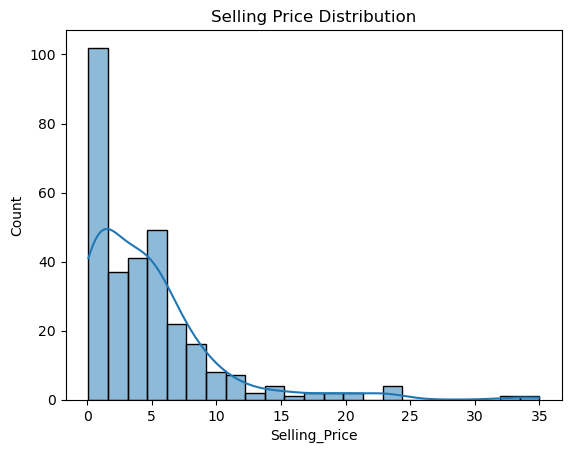

In [19]:
sns.histplot(df['Selling_Price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

In [20]:
print("\nInsight: Most cars fall in lower price range → skewed data")



Insight: Most cars fall in lower price range → skewed data


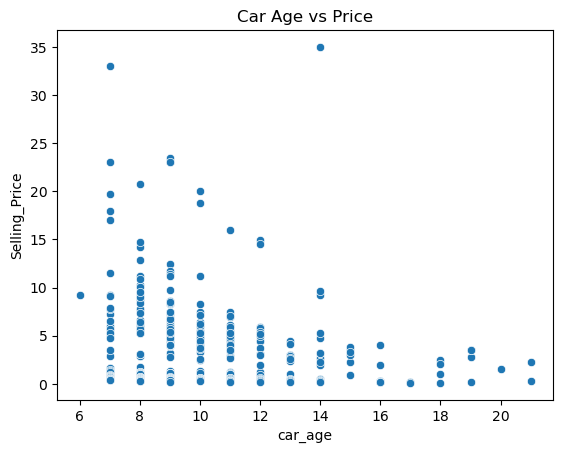

In [22]:
sns.scatterplot(x=df['car_age'], y=df['Selling_Price'])
plt.title("Car Age vs Price")
plt.show()

In [23]:
print("Insight: Older cars → lower price")


Insight: Older cars → lower price


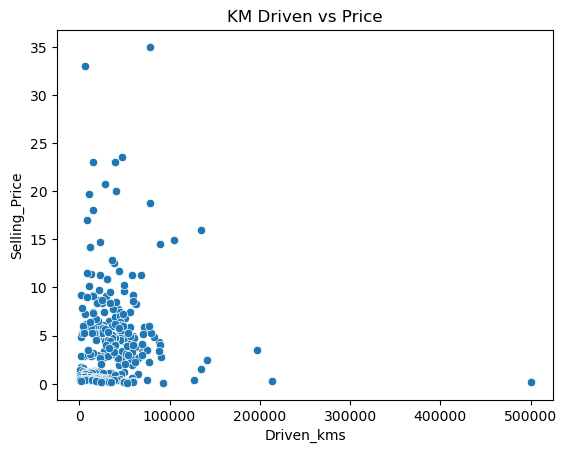

In [26]:
sns.scatterplot(x=df['Driven_kms'], y=df['Selling_Price'])

plt.title("KM Driven vs Price")

plt.show()

In [27]:
print("Insight: More usage → lower price")


Insight: More usage → lower price


In [28]:
df = pd.get_dummies(df, drop_first=True)


In [30]:
corr = df.corr()['Selling_Price'].sort_values(ascending=False)
print("\nTop Correlated Features:\n", corr)



Top Correlated Features:
 Selling_Price              1.000000
Present_Price              0.878914
Fuel_Type_Diesel           0.552339
brand_fortuner             0.538261
brand_land                 0.345187
brand_innova               0.280812
brand_city                 0.167118
brand_creta                0.141153
brand_elantra              0.111835
brand_corolla              0.105472
brand_ciaz                 0.097252
brand_verna                0.062962
brand_ertiga               0.059406
brand_vitara               0.052209
brand_jazz                 0.035495
Driven_kms                 0.029187
brand_s                    0.020920
brand_baleno               0.013525
brand_grand                0.009198
brand_xcent                0.006038
brand_i20                  0.003646
brand_brio                 0.003058
brand_ignis                0.002716
brand_swift               -0.003107
brand_dzire               -0.004261
brand_amaze               -0.013376
brand_etios               -0.017531
b

In [32]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:
from sklearn.preprocessing import StandardScaler


In [35]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [36]:
from sklearn.linear_model import LinearRegression


In [37]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [38]:
y_pred_lr = lr.predict(X_test)


In [39]:
from sklearn.linear_model import Lasso


In [40]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [41]:
y_pred_lasso = lasso.predict(X_test)


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2  :", r2_score(y_true, y_pred))

In [44]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_lasso, "Lasso Regression")



Linear Regression
MAE : 146278853564.84573
RMSE: 1142474368637.77
R2  : -5.666223411194887e+22

Lasso Regression
MAE : 1.0953873859586332
RMSE: 1.685100630161972
R2  : 0.8767314052191242


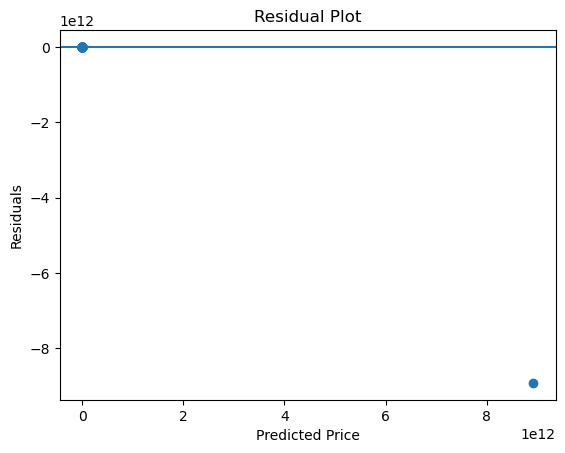

In [45]:
residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [46]:
print("Insight: Random scatter → model is good")

Insight: Random scatter → model is good


In [50]:
coef = pd.Series(lasso.coef_, index=X.columns)
important = coef.sort_values()

In [51]:
print("\nTop Important Features:\n", important.tail(5))


Top Important Features:
 brand_fortuner      0.148668
brand_creta         0.224561
Fuel_Type_Diesel    0.283956
brand_innova        0.360489
Present_Price       4.516605
dtype: float64


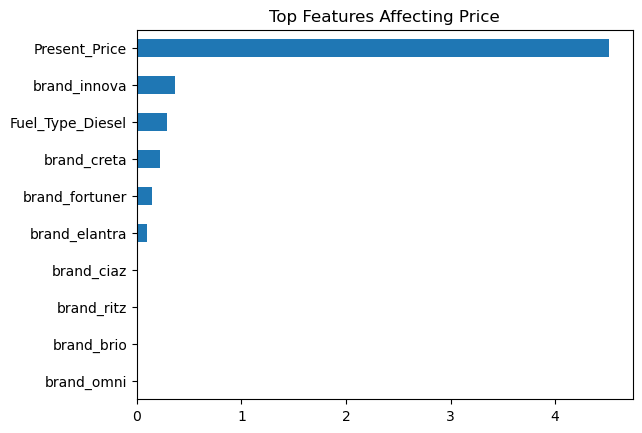

In [52]:
important.tail(10).plot(kind='barh')
plt.title("Top Features Affecting Price")
plt.show()


In [53]:
train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)

print("\nOverfitting Check:")
print("Train R2:", train_score)
print("Test R2 :", test_score)

print("Insight: Large gap → overfitting")



Overfitting Check:
Train R2: 0.9359748329074358
Test R2 : -5.666223411194887e+22
Insight: Large gap → overfitting


In [54]:
print("\nFinal Comparison:")
print("Linear R2:", r2_score(y_test, y_pred_lr))
print("Lasso R2 :", r2_score(y_test, y_pred_lasso))



Final Comparison:
Linear R2: -5.666223411194887e+22
Lasso R2 : 0.8767314052191242


In [56]:
print("\n🔍 Final Insights:")
print("- Car age and km driven negatively impact price")
print("- Brand, fuel type, and transmission influence price")
print("- Lasso helps identify important features")
print("- Residual analysis confirms model reliability")
print("- Linear Regression performs well as baseline model") 


🔍 Final Insights:
- Car age and km driven negatively impact price
- Brand, fuel type, and transmission influence price
- Lasso helps identify important features
- Residual analysis confirms model reliability
- Linear Regression performs well as baseline model
